In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../../data/product_type_2.csv", header=[0,1])
df

Process                                                     \
           id Product_Type Shot Velocity_1 Velocity_2 Velocity_3   
0     4207011            2   11      0.156      0.166      0.192   
1     4208012            2   12      0.157      0.166      0.204   
2     4209013            2   13      0.156      0.170      0.204   
3     4210014            2   14      0.154      0.170      0.202   
4     4211015            2   15      0.146      0.160      0.198   
...       ...          ...  ...        ...        ...        ...   
1959  7525657            2  657      0.144      0.173      0.200   
1960  7527658            2  658      0.144      0.173      0.200   
1961  7529659            2  659      0.150      0.166      0.210   
1962  7531660            2  660      0.144      0.174      0.206   
1963  7533661            2  661      0.147      0.174      0.204   

                                                                        ...  \
     High_Velocity Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  ...   
0            2.723               265           0.012                20  ...   
1            2.730               264           0.014                19  ...   
2            2.715               265           0.012                18  ...   
3            2.717               264           0.011                20  ...   
4            2.684               264           0.012                20  ...   
...            ...               ...             ...               ...  ...   
1959         2.536               264           0.012                17  ...   
1960         2.536               264           0.012                17  ...   
1961         2.492               265           0.011                17  ...   
1962         2.514               264           0.011                16  ...   
1963         2.532               265           0.012                18  ...   

     Defects                                                          \
     Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2   
0          0      0             0               0          0       0   
1          0      0             0               0          0       0   
2          0      0             0               0          0       0   
3          0      0             0               0          0       0   
4          0      0             0               0          0       0   
...      ...    ...           ...             ...        ...     ...   
1959       0      0             0               0          0       0   
1960       0      0             0               0          0       0   
1961       0      0             0               0          0       0   
1962       0      0             0               0          0       0   
1963       0      0             0               0          0       0   

                                          Defect_Flag  
     Scratch_2 Buring_Mark_2 Inclusions_2   Is_Defect  
0            0             0            0           0  
1            0             0            0           0  
2            0             0            0           0  
3            0             0            0           0  
4            0             0            0           0  
...        ...           ...          ...         ...  
1959         0             0            0           0  
1960         0             0            0           0  
1961         0             0            0           0  
1962         0             0            0           1  
1963         0             0            0           1  

[1964 rows x 58 columns]

In [57]:
# 불필요한 id, product_type 컬럼 제거
df = df.drop(columns=[('Process', 'id'), ('Process', 'Product_Type')])

In [58]:
print("결측치 상위:\n", df.isnull().sum().sort_values(ascending=False).head(10))

print("\n불량 비율:\n", df[('Defect_Flag','Is_Defect')].value_counts(normalize=True))

결측치 상위:
 Sensor   Factory_Temp            45
         Factory_Humidity        45
         Factory_Temp_Max        45
         Factory_Humidity_Max    45
         Factory_Humidity_Min    45
         Factory_Temp_Min        45
Process  Velocity_2               0
         Shot                     0
         Biscuit_Thickness        0
         Clamping_Force           0
dtype: int64

불량 비율:
 (Defect_Flag, Is_Defect)
0    0.746945
1    0.253055
Name: proportion, dtype: float64


In [ ]:
y = df[('Defect_Flag','Is_Defect')]

X = df[['Process','Sensor']].copy()

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
print("train:", X_train.shape)
print("test:", X_test.shape)

print("train 불량률:", y_train.mean())
print("test 불량률:", y_test.mean())

train: (1571, 29)
test: (393, 29)
train 불량률: 0.25334182049649906
test 불량률: 0.25190839694656486


In [62]:
# 숫자 컬럼만
X_train_num = X_train.select_dtypes(include="number")

In [63]:
Q1 = X_train_num.quantile(0.25)
Q3 = X_train_num.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [64]:
iqr_summary = pd.DataFrame({
    "이상치 갯수": ((X_train_num < lower) | (X_train_num > upper)).sum()
})

# 이상치 비율 추가
iqr_summary["이상치 비율(%)"] = (
    iqr_summary["이상치 갯수"] / len(X_train_num) * 100
)

# 이상치 있는 컬럼 수
outlier_col_count = (iqr_summary["이상치 갯수"] > 0).sum()
print("이상치가 존재하는 컬럼 수:", outlier_col_count)

이상치가 존재하는 컬럼 수: 8


In [65]:
import numpy as np
import pandas as pd

top11_cols = iqr_summary[iqr_summary["이상치 갯수"] > 0].head(11).index

rows = []
for col in top11_cols:
    s = X_train_num[col].dropna()

    lower_val = lower[col]
    upper_val = upper[col]

    mean_val = s.mean()
    min_val  = s.min()
    max_val  = s.max()

    out_mask = (s < lower_val) | (s > upper_val)
    out_cnt = int(out_mask.sum())
    out_rate = out_cnt / len(s) * 100 if len(s) else np.nan

    if mean_val == 0 or np.isclose(mean_val, 0):
        min_pct = np.nan
        max_pct = np.nan
    else:
        min_pct = (min_val - mean_val) / mean_val * 100
        max_pct = (max_val - mean_val) / mean_val * 100

    name = col[1] if isinstance(col, tuple) and len(col) > 1 else str(col)

    rows.append({
        "col": name,
        "최소값": min_val,
        "평균": mean_val,
        "최대값": max_val,
        "min_vs_mean_%": min_pct,
        "max_vs_mean_%": max_pct,
        "outlier_cnt": out_cnt,
        "outlier_rate_%": out_rate,
        "IQR": float(IQR[col])
    })

viz_df = pd.DataFrame(rows).sort_values("outlier_rate_%", ascending=False).reset_index(drop=True)

display(viz_df)

,col,최소값,평균,최대값,min_vs_mean_%,max_vs_mean_%,outlier_cnt,outlier_rate_%,IQR
0,Biscuit_Thickness,2.000,17.533418,24.000,-88.593211,36.881467,224,14.258434,1.000
1,Rapid_Rise_Time,0.009,0.011692,0.014,-23.023737,19.740854,118,7.511139,0.001
2,Spray_1_Time,2.000,2.025271,2.500,-1.247761,23.440299,86,5.474220,0.000
3,Velocity_3,0.184,0.202377,0.216,-9.080501,6.731586,39,2.482495,0.006
4,Casting_Pressure,556.000,595.329090,597.000,-6.606277,0.280670,27,1.718651,1.000
5,Cylinder_Pressure,247.000,264.702737,266.000,-6.687780,0.490083,6,0.381922,1.000
6,Cycle_Time,33.600,35.525016,125.900,-5.418762,254.398152,5,0.318269,2.100
7,Factory_Temp,27.400,33.063696,37.000,-17.129651,11.905216,1,0.065062,2.800


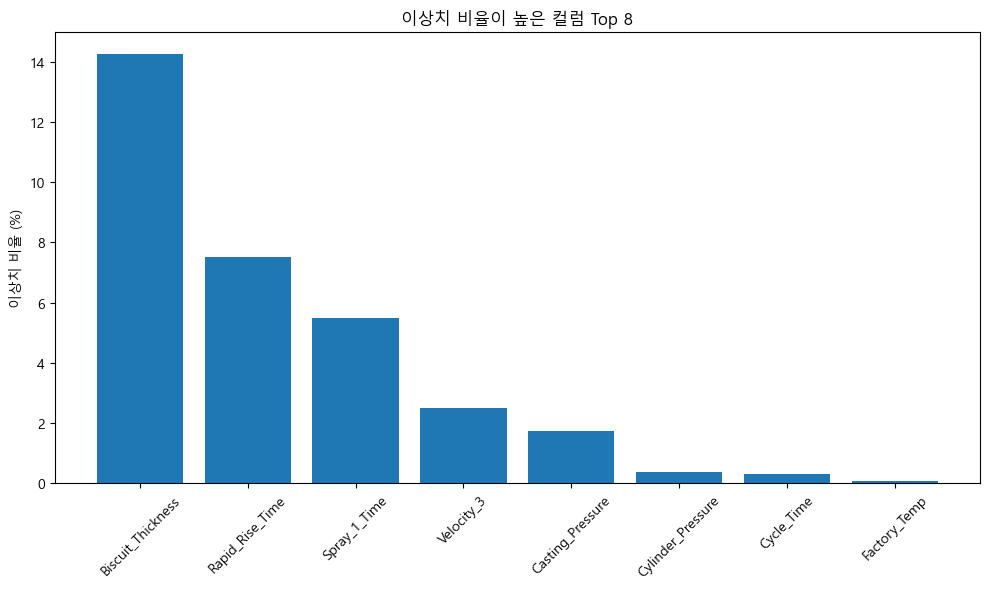

In [53]:
import matplotlib.pyplot as plt

top8 = iqr_summary.sort_values("이상치 비율(%)", ascending=False).head(8)

labels = [col[1] for col in top8.index]   # MultiIndex에서 컬럼명만 추출
values = top8["이상치 비율(%)"]

plt.figure(figsize=(10,6))

plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("이상치 비율 (%)")
plt.title("이상치 비율이 높은 컬럼 Top 8")

plt.tight_layout()
plt.show()

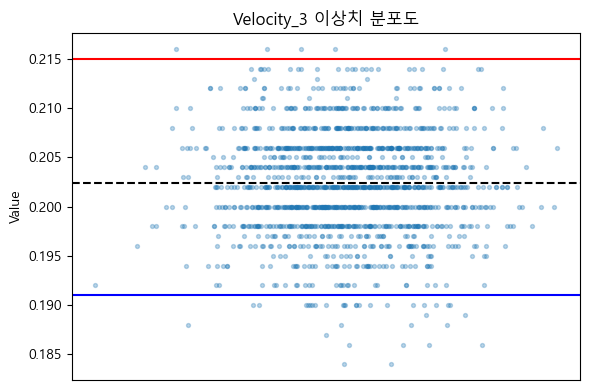

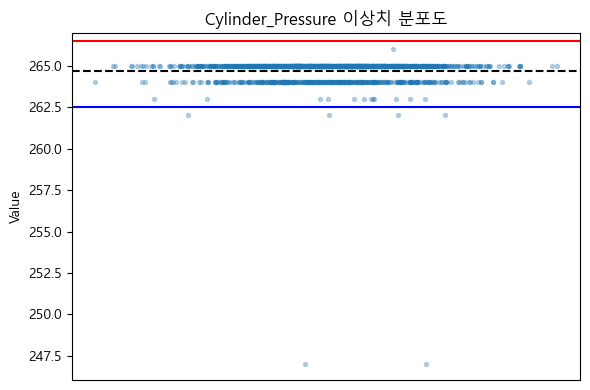

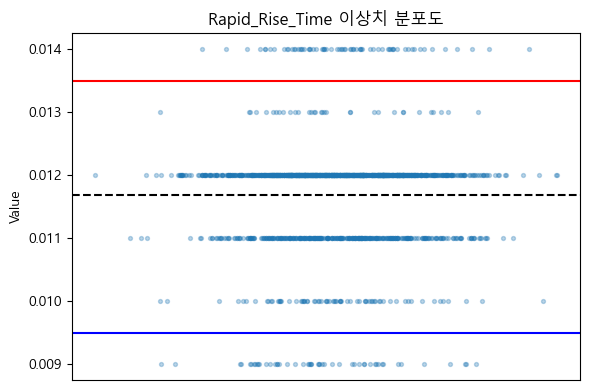

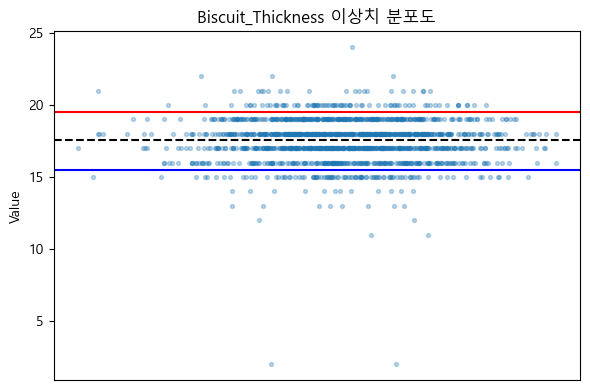

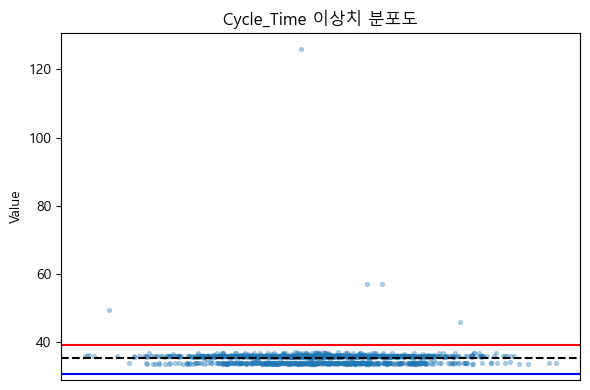

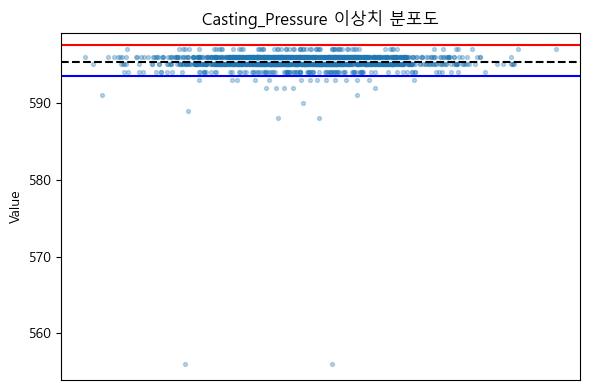

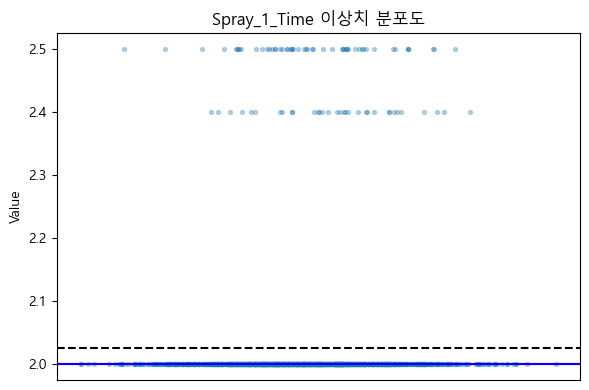

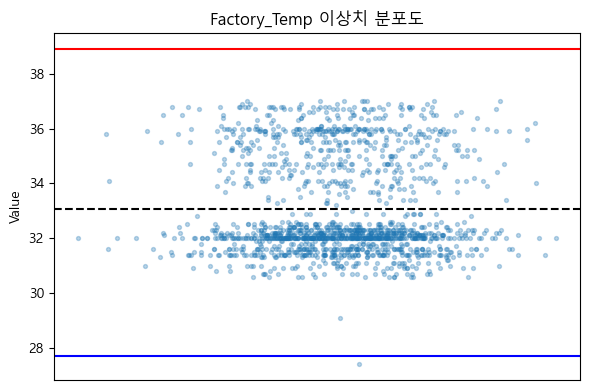

In [66]:
top8_cols = iqr_summary.sort_values("이상치 비율(%)", ascending=False).head(8).index

for col in top11_cols:

    s = X_train_num[col].dropna()

    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(6,4))

    # x값 점 간격
    x = np.random.normal(0, 0.04, size=len(s))

    plt.scatter(x, s, alpha=0.3, s=8)

    # 평균선 (검정)
    mean_val = s.mean()
    plt.axhline(mean_val, linestyle="--", color="black")

    # 이상치 경계선
    lower_val = lower[col]
    upper_val = upper[col]

    plt.axhline(upper_val, color="red")   # 상한선
    plt.axhline(lower_val, color="blue")  # 하한선

    title_name = col[1] if isinstance(col, tuple) else str(col)

    plt.title(f"{title_name} 이상치 분포도")
    plt.ylabel("Value")
    plt.xticks([])

    plt.tight_layout()
    plt.show()

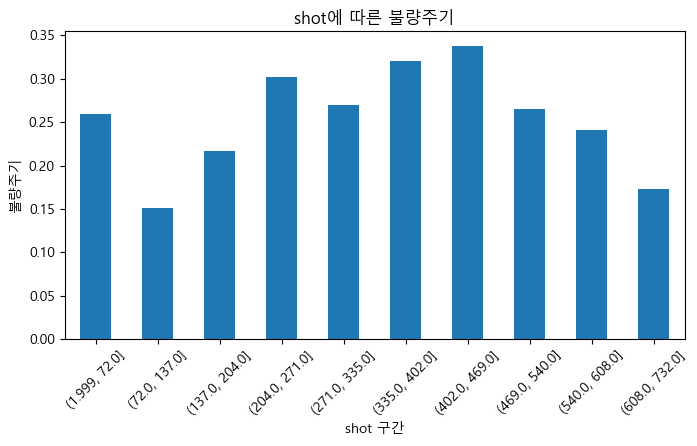

In [45]:
df_tmp = pd.DataFrame({
    "Shot": X_train[('Process','Shot')],
    "Defect": y_train
})

# Shot을 10구간으로 나누기
df_tmp["Shot_bin"] = pd.qcut(df_tmp["Shot"], 10)

shot_defect = df_tmp.groupby("Shot_bin")["Defect"].mean()

shot_defect.plot(kind="bar", figsize=(8,4))
plt.xticks(rotation=45)
plt.xlabel("shot 구간")
plt.ylabel("불량주기")
plt.title("shot에 따른 불량주기")
plt.show()